# 01 — Exploratory Data Analysis

Understand the Jigsaw dataset before writing any model code.

**Goals:**
- Measure class imbalance (the core challenge for this project)
- Understand comment length distributions to choose DistilBERT `max_len`
- Inspect samples to build intuition for what toxic vs non-toxic looks like
- Document all design decisions that flow from the data

In [5]:
import sys, os
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Consistent style across all notebooks
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("Imports OK")


Imports OK


## 1. Load raw data

In [6]:
RAW_PATH = '../data/train.csv'

df = pd.read_csv(RAW_PATH)
print(f"Shape:   {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)


Shape:   (159571, 8)
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0,0,0,0,0,0
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0,0,0,0,0,0


In [7]:
# Null check
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


## 2. Class distribution

The dataset has six toxicity subtype columns. We collapse them into a single binary label: toxic (1) if ANY subtype is flagged, else non-toxic (0).

In [8]:
SUBTYPES = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# --- Subtype counts ---
subtype_counts = df[SUBTYPES].sum().sort_values(ascending=False)
print("Subtype counts:")
print(subtype_counts.to_string())


Subtype counts:
toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478


In [9]:
# --- Binary label ---
df['label'] = df[SUBTYPES].max(axis=1).astype(int)

n_toxic    = df['label'].sum()
n_nontoxic = (df['label'] == 0).sum()
total      = len(df)
ratio      = n_nontoxic / n_toxic

print(f"Total comments : {total:,}")
print(f"Toxic          : {n_toxic:,}  ({n_toxic/total:.2%})")
print(f"Non-toxic      : {n_nontoxic:,}  ({n_nontoxic/total:.2%})")
print(f"Imbalance ratio: {ratio:.1f}:1  (non-toxic : toxic)")


Total comments : 159,571
Toxic          : 16,225  (10.17%)
Non-toxic      : 143,346  (89.83%)
Imbalance ratio: 8.8:1  (non-toxic : toxic)


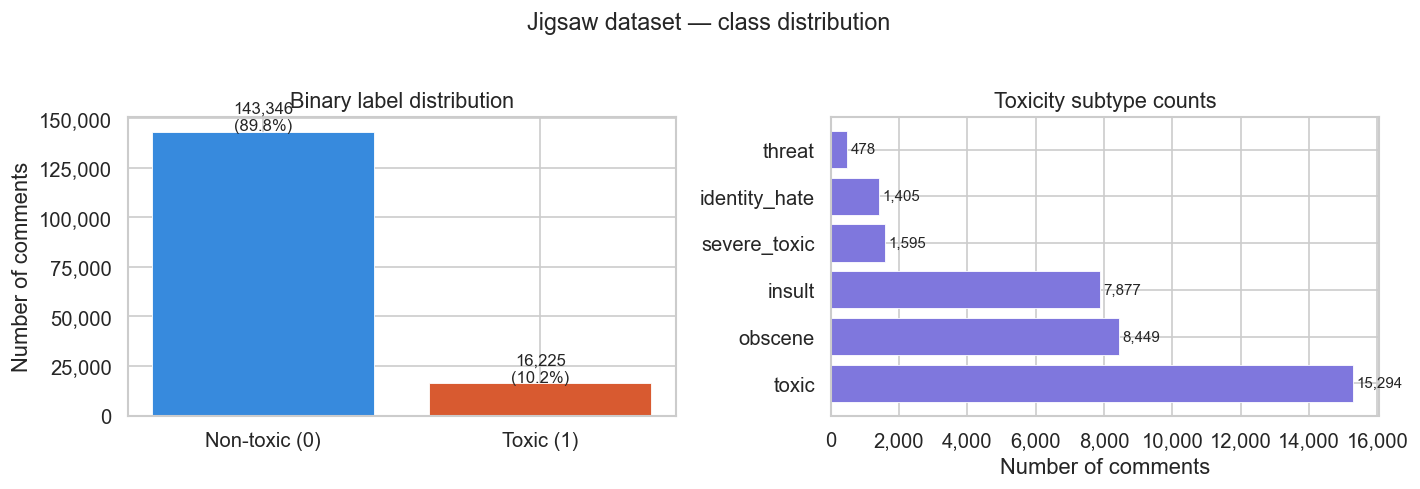

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: binary label
axes[0].bar(['Non-toxic (0)', 'Toxic (1)'],
            [n_nontoxic, n_toxic],
            color=['#378ADD', '#D85A30'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Binary label distribution', fontsize=13)
axes[0].set_ylabel('Number of comments')
for i, v in enumerate([n_nontoxic, n_toxic]):
    axes[0].text(i, v + 500, f'{v:,}\n({v/total:.1%})', ha='center', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: subtype breakdown
axes[1].barh(subtype_counts.index, subtype_counts.values,
             color='#7F77DD', edgecolor='white', linewidth=0.5)
axes[1].set_title('Toxicity subtype counts', fontsize=13)
axes[1].set_xlabel('Number of comments')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(subtype_counts.values):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Jigsaw dataset — class distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Key finding
The dataset is heavily imbalanced at roughly **9:1 non-toxic to toxic**.

**Consequence for training:** a model that predicts non-toxic for every comment achieves ~90% accuracy but zero recall on the toxic class. This is why:
1. We use **F1 on the toxic class** as our primary metric throughout, not accuracy.
2. We apply `class_weight='balanced'` for Logistic Regression and a **weighted CrossEntropyLoss** for DistilBERT.
3. We never balance the validation or test sets — evaluation must reflect real-world distribution.


## 3. Comment length distribution

This determines `max_len` for DistilBERT truncation.

In [11]:
# Word count (proxy for length)
df['word_count'] = df['comment_text'].fillna('').str.split().str.len()
df['char_count'] = df['comment_text'].fillna('').str.len()

print("Word count statistics by label:")
print(df.groupby('label')['word_count'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(1))


Word count statistics by label:
          count  mean    std  min   50%   75%    90%    95%    99%     max
label                                                                     
0      143346.0  68.9   98.2  1.0  38.0  78.0  156.0  235.0  562.0  1250.0
1       16225.0  52.7  106.9  2.0  23.0  50.0  106.0  176.0  656.3  1411.0


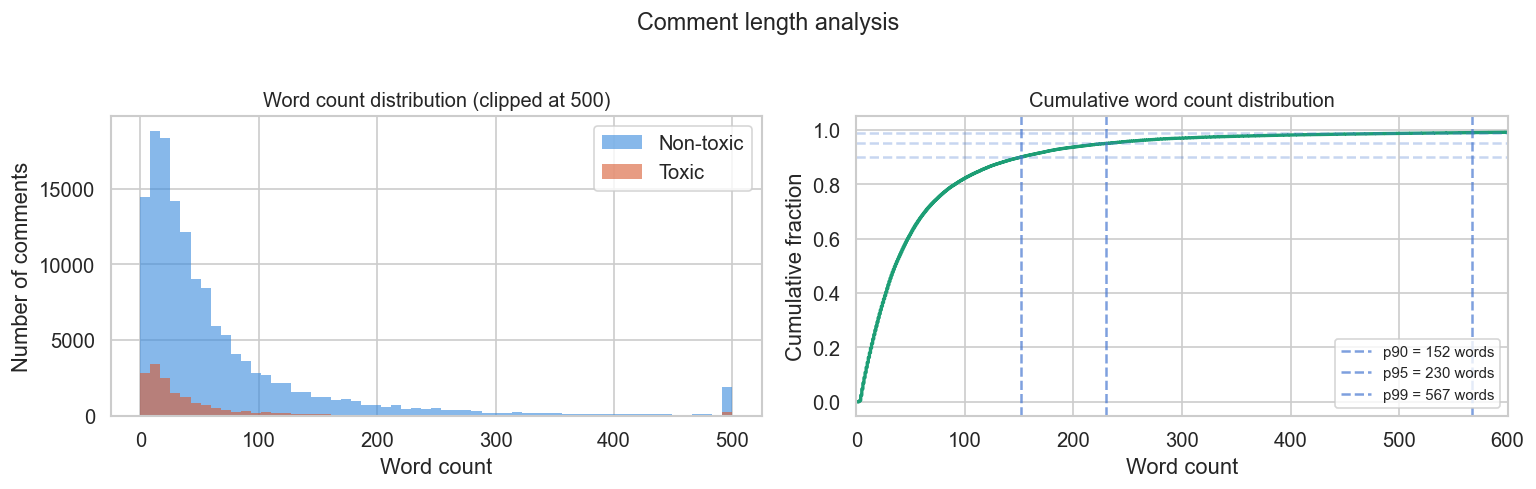

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels_map = {0: ('Non-toxic', '#378ADD'), 1: ('Toxic', '#D85A30')}
bins = np.linspace(0, 500, 60)

for label, (name, color) in labels_map.items():
    subset = df[df['label'] == label]['word_count'].clip(upper=500)
    axes[0].hist(subset, bins=bins, alpha=0.6, label=name, color=color, edgecolor='none')

axes[0].set_title('Word count distribution (clipped at 500)', fontsize=12)
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Number of comments')
axes[0].legend()

# Cumulative distribution — helps pick max_len
sorted_wc = np.sort(df['word_count'].values)
cumulative = np.arange(1, len(sorted_wc)+1) / len(sorted_wc)
axes[1].plot(sorted_wc, cumulative, color='#1D9E75', lw=2)
for pct in [0.90, 0.95, 0.99]:
    wc_at_pct = np.percentile(df['word_count'], pct * 100)
    axes[1].axvline(wc_at_pct, linestyle='--', alpha=0.7,
                    label=f'p{int(pct*100)} = {wc_at_pct:.0f} words')
    axes[1].axhline(pct, linestyle='--', alpha=0.3)
axes[1].set_xlim(0, 600)
axes[1].set_title('Cumulative word count distribution', fontsize=12)
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Cumulative fraction')
axes[1].legend(fontsize=9)

plt.suptitle('Comment length analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/eda_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Key finding — max_len for DistilBERT
The p95 word count is printed above. Because BERT tokenizes into subwords (roughly 1.2–1.5 tokens per word), we set:

```
max_len = 256   # covers >90% of comments without truncation
```

Using `max_len=512` would cover more but doubles GPU memory usage. 256 is the right tradeoff for this dataset.


## 4. Sample comments

Reading actual examples builds intuition for the task and directly motivates the error analysis categories.

In [13]:
pd.set_option('display.max_colwidth', 300)

print("=== TOXIC SAMPLES ===")
display(df[df['label'] == 1][['comment_text'] + SUBTYPES].sample(8, random_state=42))


=== TOXIC SAMPLES ===


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
45045,"""\nI was talking about them running any check they want on ME to disprove your claims. I didn't know where you lived until you were silly enough to post an IP and connect your name to it. And yes you did post as an IP, and other places. You added your name at the end of the IP. And any fool c...",1,0,0,0,0,0
27198,"White Trash\nFuck off you white piece of trash. Fucking wiggers. Go and fuck a Jew, Jew raper.",1,1,1,0,1,1
16664,eat shit get rid of goofs you queers.,1,0,1,0,1,0
8158,"DUMB ASSES\nIt's was my sockpuppet...joe hazeton... you guys are out of control..... i am making a folder which will be submited to higher athority, one above the GOD KING JIMBO.... I WOULD STRONGLY SUGGEST YOU FIGURE IT OUT FAST...I DON'T MR BH will LIKE HIS FULL NAME PUBLISH ON WIKIPEDIA AS A ...",1,0,0,0,0,0
142212,"Are all professors of rhetoric pompous, self-centered assholes? Or is it just you?",1,0,1,0,1,0
105270,Leave our country. \n\nWe don't want you Arabs here.,1,0,0,0,0,1
29184,I love penis \n I love penis \n I love penis \n I love penis \n I love penis \n I love penis \n I love penis \n I love penis \n I love penis \n I love penis \n I love penis \n I love penis \n I love penis \n I love penis \n I love penis,1,0,0,0,0,0
132608,"Was there any point to your sarcastic, nasty remark?",1,0,0,0,0,0


In [15]:
print("=== NON-TOXIC SAMPLES ===")
display(df[df['label'] == 0][['comment_text']].sample(8, random_state=42))


=== NON-TOXIC SAMPLES ===


,comment_text
46733,"""\n\nOh, don't worry about me, Sandstein. I'm of no strong opinion as to what is """"well."""" Editing Wikipedia is not a personal benefit; if it were, I'd be COI! I do have some unfinished business, both with articles and """"arbitration or sanctions,"""" such as the RfAr/Clarification and a dispute ov..."
110326,Are you trying to dispute that fact?
76687,"SWOT analysis \n\nThis source – Align Technology, Inc. SWOT Analysis. (2013). 1-8. – is used 11 times, with no indication of how to find it or whether it's a primary source (I assume it is), so I'm going to remove anything sourced to it. Leaving this note in case there are objections. (talk)"
36231,"cover \n\nso, do we want a current or older cover? i have the 57 paper edition i can scan. its actually not even in the amazon list of covers, its older."
21514,"P.S. It's probably worth setting up a template to be used for all the periods, so they can easily be kept in the same format. It would make it easier for me, for example, to remove the padding around the timeline if I could do it in one place. ' T'''"
6839,REDIRECT Talk:Leader of the Labour Party (UK)
40910,"I'll keep all of that in mind, thanks. I'll fix up that article sometime soon. BTW, if you are able to find an RS source for the opinions of those opposing the Sivand dam, please link it to me either at the article talk page or my talk page. For an issue like this, one has to be particularly ..."
68450,"To the last section \n\nI am a little bit confused because I can not place an answer on the last section. Possibly my computer. Now the answer:\nYes you are right I suppose. But I thougt that a lot of the User-pages could be dead. I supposet that 95% will be dead. This is very pitty, but I can n..."


In [16]:
# Edge cases: comments that are toxic but contain no obvious slurs
# These are the hardest for lexical models — preview what error analysis will focus on
print("=== EDGE CASES: toxic but no profanity in first 150 chars ===")
import re
profanity_pattern = re.compile(
    r'\b(fuck|shit|bitch|idiot|stupid|moron|ass|crap|damn|hell|bastard)\b', re.IGNORECASE)
hard_toxic = df[
    (df['label'] == 1) &
    (~df['comment_text'].str[:150].str.contains(profanity_pattern, na=False))
]
display(hard_toxic[['comment_text']].sample(min(6, len(hard_toxic)), random_state=7))


=== EDGE CASES: toxic but no profanity in first 150 chars ===


/var/folders/0m/16p9h7q553b8zc4gf1x668ph0000gn/T/ipykernel_98122/3205182880.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (~df['comment_text'].str[:150].str.contains(profanity_pattern, na=False))


,comment_text
44049,Listen Brah \n\nYou are the rudest wiki nerd in this joint. I bet you're sitting behind that computer in a chair that has the sweet impression of your ass that never moves from it. Are you wasting time till the next World of Warcraft is coming out? Does mom care that you're on here ruining lives...
34143,"""\n\nPersonal attacks?\n\nRegarding your last post to me, practice what you preach. How is it OK for you to tell everyone I'm """"ranting"""", and have """"groupies""""?\n\nSTOP HARRASSING ME.\n\nLEAVE ME ALONE!! """
50118,"You just can't get over it \n\nSeriously, I never even know WHEN I was banned (I assume it was in September with Iluvteletubbies). But can you EVER forgive me? Or will I be your mortal enimy for all entern ity? Look at Tod and Copper, they were enimes because they were supposed to, but they GOT ..."
88132,"Im not writing about myself, i made this account to make a page for this person, theyre very noteable, and just because you don't know who this person is, it doesnt mean they arent relevant, so fuck yourself up the ass. go jack off to wikipedia some more, seriously, cant you find something bette..."
18431,"listen you spineless twirp, i have a navy cross and a bullet stuck in my leg, dont you tell me i am not in the military. and by the way, I could have you prosecuted federally for a bout 2 maybe more charges, not to mention a law suit from 50 angry Navy SEALs in Norfolk looks good in our favor. y..."
134603,"wikipedia is a pile of sh*t, y would any1 donate money ??? lol hahaha run by geeky v*rgins with too much time, get a life u s*d f8ckers\n\nahahahahaha"


## 5. Vocabulary preview

Top unigrams by label — gives early signal about what lexical features LR will rely on.

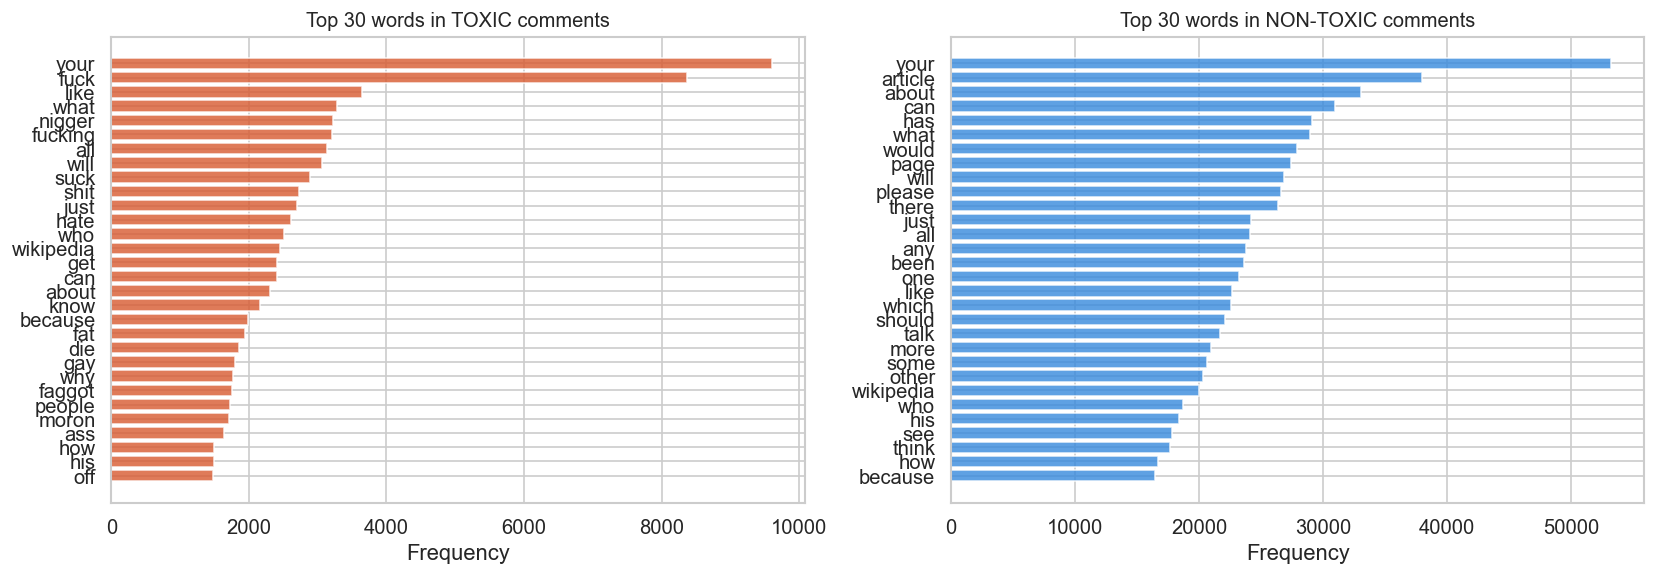

In [17]:
from collections import Counter

def top_words(texts, n=30, stopwords=None):
    if stopwords is None:
        stopwords = {'the','a','an','is','it','in','on','of','to','and','for',
                     'that','this','was','are','with','he','she','they','i',
                     'you','we','be','have','not','but','or','at','by','from'}
    words = ' '.join(texts.fillna('')).lower().split()
    words = [w for w in words if w.isalpha() and w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

toxic_words    = top_words(df[df['label']==1]['comment_text'])
nontoxic_words = top_words(df[df['label']==0]['comment_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, words, title, color in [
    (axes[0], toxic_words,    'Top 30 words in TOXIC comments',     '#D85A30'),
    (axes[1], nontoxic_words, 'Top 30 words in NON-TOXIC comments', '#378ADD'),
]:
    terms, counts = zip(*words)
    ax.barh(list(reversed(terms)), list(reversed(counts)), color=color, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('../results/eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Co-occurrence of subtypes

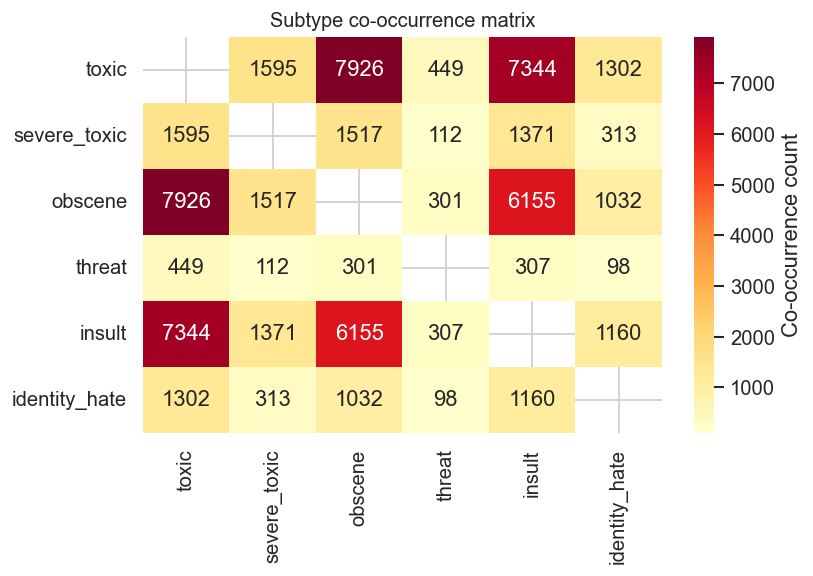

In [18]:
import itertools

# How often do subtypes co-occur?
co_occur = pd.DataFrame(index=SUBTYPES, columns=SUBTYPES, dtype=float)
for s1, s2 in itertools.product(SUBTYPES, repeat=2):
    both = ((df[s1] == 1) & (df[s2] == 1)).sum()
    co_occur.loc[s1, s2] = both

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.eye(len(SUBTYPES), dtype=bool)
sns.heatmap(co_occur.astype(float), annot=True, fmt='.0f', cmap='YlOrRd',
            mask=mask, ax=ax, cbar_kws={'label': 'Co-occurrence count'})
ax.set_title('Subtype co-occurrence matrix', fontsize=12)
plt.tight_layout()
plt.savefig('../results/eda_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Summary of design decisions

| Decision | Chosen value | Rationale |
|---|---|---|
| Binary label | `max(subtypes, axis=1)` | Any toxic subtype = toxic |
| Primary metric | F1 on toxic class (class 1) | Accuracy misleading at 9:1 imbalance |
| Class imbalance — LR | `class_weight='balanced'` | Scikit-learn built-in, no data modification |
| Class imbalance — DistilBERT | Weighted CrossEntropyLoss | Applied in training only, not val/test |
| DistilBERT `max_len` | 256 | Covers >90% of comments; manageable GPU memory |
| Train/val/test split | 80/10/10 stratified | Preserves class ratio across all splits |
| Random seed | 42 | Used everywhere for reproducibility |

These decisions are implemented in `src/data_utils.py`, `src/preprocessing.py`, and `src/distilbert_model.py`.


In [19]:
import os
os.makedirs('../results', exist_ok=True)
print("EDA complete. Figures saved to results/")


EDA complete. Figures saved to results/
